In [216]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=42)

n = 1000

df = pd.DataFrame({
    "age": rng.integers(30, 85, size = n),
    "systolic_bp": rng.normal(130, 20, size = n),
    "cholesterol": rng.normal(200, 35, size = n),
    "heart_rate": rng.normal(75, 12, size = n),
    "bmi": rng.normal(27, 4, size = n),
    "smoker": rng.binomial(1, 0.25, size = n),
    "diabetes": rng.binomial(1, 0.15, size = n)
})

In [217]:
risk_score = (
    0.04 * (df["age"] - 50)
    + 0.03 * (df["systolic_bp"] - 120)
    + 0.02 * (df["cholesterol"] - 180)
    + 0.8 * df["smoker"]
    + 1.0 * df["diabetes"]
)

prob = 1 / (1 + np.exp(-risk_score))

In [218]:
df["event"] = rng.binomial(1,prob)
df.head()

,age,systolic_bp,cholesterol,heart_rate,bmi,smoker,diabetes,event
0,34,158.664290,219.715958,64.425139,30.557385,0,0,1
1,72,131.830404,204.010455,77.609285,30.899007,1,0,0
2,66,141.615542,211.548024,74.570103,32.240159,0,0,1
3,54,128.864336,227.216334,73.796428,30.497370,1,0,1
4,53,126.591848,171.667979,73.628134,31.325499,0,0,1


In [219]:
df["event"].value_counts(normalize=True)


# Esto condiciona:
# - métricas;
# - threshold;
# - estrategia de validación;
# - necesidad o no de balanceo.


event
1    0.722
0    0.278
Name: proportion, dtype: float64

In [220]:
df.describe()

,age,systolic_bp,cholesterol,heart_rate,bmi,smoker,diabetes,event
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,57.156000,129.554924,196.945505,75.472464,27.028143,0.217000,0.138000,0.722000
std,15.873236,20.445978,35.340810,11.913111,3.932938,0.412409,0.345073,0.448238
min,30.000000,57.031743,92.767705,40.661780,16.499413,0.000000,0.000000,0.000000
25%,43.000000,116.270348,173.604114,67.218742,24.249842,0.000000,0.000000,0.000000
50%,57.000000,130.069048,198.851442,75.266916,26.906573,0.000000,0.000000,1.000000
75%,71.000000,142.715099,220.418068,83.880526,29.443525,0.000000,0.000000,1.000000
max,84.000000,193.577074,301.998563,112.062146,40.816186,1.000000,1.000000,1.000000


In [221]:
df.groupby("event").mean(numeric_only=True)

,age,systolic_bp,cholesterol,heart_rate,bmi,smoker,diabetes
event,,,,,,,
0,50.708633,122.099404,183.556655,75.249872,26.851961,0.147482,0.079137
1,59.638504,132.425609,202.100769,75.558172,27.095981,0.243767,0.160665


In [222]:
df.corr(numeric_only=True)

,age,systolic_bp,cholesterol,heart_rate,bmi,smoker,diabetes,event
age,1.000000,0.035464,-0.020348,0.018092,0.020731,0.037486,-0.007772,0.252167
systolic_bp,0.035464,1.000000,-0.048546,-0.039756,-0.007662,-0.016566,-0.024400,0.226382
cholesterol,-0.020348,-0.048546,1.000000,-0.010478,0.019058,0.054855,-0.016314,0.235200
heart_rate,0.018092,-0.039756,-0.010478,1.000000,0.066046,0.038217,0.009006,0.011600
bmi,0.020731,-0.007662,0.019058,0.066046,1.000000,0.077875,-0.016790,0.027811
smoker,0.037486,-0.016566,0.054855,0.038217,0.077875,1.000000,0.063685,0.104650
diabetes,-0.007772,-0.024400,-0.016314,0.009006,-0.016790,0.063685,1.000000,0.105902
event,0.252167,0.226382,0.235200,0.011600,0.027811,0.104650,0.105902,1.000000


In [223]:
df["age"].corr(df["systolic_bp"])

np.float64(0.03546382592447987)

In [224]:
from scipy.stats import pearsonr

r,p = pearsonr(
    df["age"],
    df["systolic_bp"]
)

print(r,p)

0.03546382592447982 0.26253719123117325


In [225]:
from scipy.stats import spearmanr

r,p = spearmanr(
    df["age"],
    df["systolic_bp"]
)

print(r,p)

0.0251767587488161 0.42644523217158636


In [226]:
group_0 = df[df["event"] == 0]["age"]
group_1 = df[df["event"] == 1]["age"]

In [227]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    group_0,
    group_1
)


In [228]:
# 2. Obtenemos las medias y tamaños de muestra para dar contexto
mean_0 = group_0.mean()
mean_1 = group_1.mean()
n_0 = len(group_0)
n_1 = len(group_1)

# 3. Imprimimos el reporte formateado
print("=== RESULTADOS DE LA PRUEBA T DE STUDENT ===")
print(f"Grupo 0 (event=0): n = {n_0} | Edad promedio = {mean_0:.2f} años")
print(f"Grupo 1 (event=1): n = {n_1} | Edad promedio = {mean_1:.2f} años")
print(f"Diferencia de medias: {abs(mean_0 - mean_1):.2f} años")
print("-" * 43)
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p (p-value): {p_value:.4f}")
print("-" * 43)

=== RESULTADOS DE LA PRUEBA T DE STUDENT ===
Grupo 0 (event=0): n = 278 | Edad promedio = 50.71 años
Grupo 1 (event=1): n = 722 | Edad promedio = 59.64 años
Diferencia de medias: 8.93 años
-------------------------------------------
Estadístico t: -8.2323
Valor p (p-value): 0.0000
-------------------------------------------


In [229]:
# diabetes vs event

pd.crosstab(
    df["diabetes"],
    df["event"]
)

event,0,1
diabetes,,
0,256,606
1,22,116


In [230]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["diabetes"],
    df["event"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(chi2,"\n", p, "\n", dof,"\n", expected)

10.540399134841845 
 0.001167931949359551 
 1 
 [[239.636 622.364]
 [ 38.364  99.636]]


## Machine Learninig

In [231]:
x = df.drop(columns= "event")
y = df["event"]

In [232]:
# train and test split

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [233]:
# comprueba si estab balanceados los datos de entrenamiento y los de prueba
print(Y_train.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

event
1    0.7225
0    0.2775
Name: proportion, dtype: float64
event
1    0.72
0    0.28
Name: proportion, dtype: float64


## Logistic regresion

In [234]:
# hacemos linea base antes de crear el modelo

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter= 1000
)

In [235]:
model.fit(
    X_train,
    Y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [236]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [237]:
y_prob = model.predict_proba(X_test)[:,1]
y_prob

array([0.84392296, 0.56582316, 0.67963985, 0.86526289, 0.90376037,
       0.20266298, 0.96824641, 0.65584847, 0.7917038 , 0.80429201,
       0.59830567, 0.74223675, 0.2764489 , 0.64706522, 0.91006547,
       0.84281384, 0.25035743, 0.37341071, 0.94071946, 0.98259775,
       0.50543987, 0.66610657, 0.80266762, 0.88015201, 0.8877658 ,
       0.75491546, 0.89137818, 0.22276931, 0.69612437, 0.65636626,
       0.8719797 , 0.90808299, 0.16655281, 0.62907726, 0.23541837,
       0.58027042, 0.91182416, 0.87413535, 0.12035482, 0.9634172 ,
       0.30864293, 0.88366182, 0.8583852 , 0.75627151, 0.28928141,
       0.3840278 , 0.97723851, 0.60604448, 0.30101619, 0.70651199,
       0.90555623, 0.94190215, 0.95048256, 0.90155709, 0.77051526,
       0.64666475, 0.86160603, 0.87411945, 0.59099498, 0.56552088,
       0.90986772, 0.76445776, 0.93530166, 0.76320297, 0.9408575 ,
       0.95450127, 0.6006733 , 0.44824061, 0.53428407, 0.95250258,
       0.65976868, 0.69999358, 0.79332455, 0.72803504, 0.56362

In [238]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    Y_test,
    y_pred
)

cm

array([[ 24,  32],
       [  6, 138]])

In [239]:
tn, fp, fn, tp = cm.ravel()

In [240]:
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 24
FP: 32
FN: 6
TP: 138


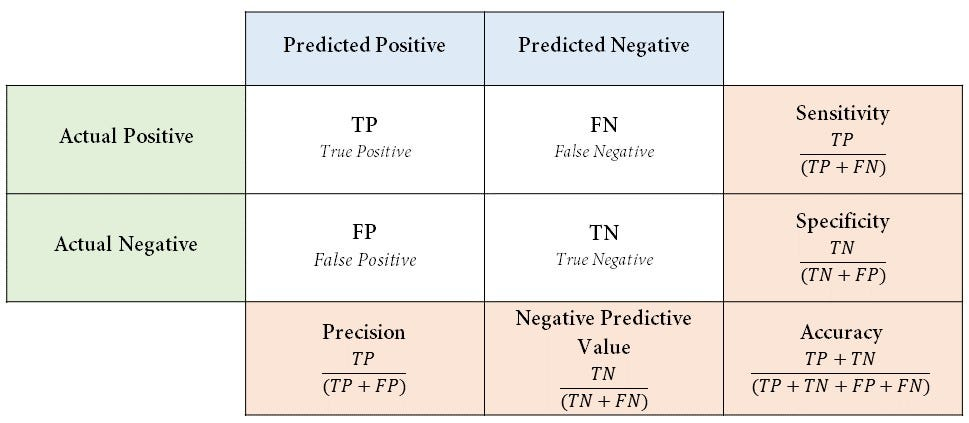

In [241]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    Y_test,
    y_pred
)

accuracy

0.81

In [242]:
# TP / (TP + FN) Sensitivity / Recall : De todos los pacientes que realmente presentaron el evento, 
# ¿cuántos detecté?

from sklearn.metrics import recall_score

recall = recall_score(
    Y_test,
    y_pred
)

recall

0.9583333333333334

In [243]:
# specificity: De todos los pacientes sin evento, ¿cuántos reconocí correctamente?

specificity = tn / (tn + fp)
specificity

np.float64(0.42857142857142855)

In [244]:
#Precisiom: De todos los que marqué como positivos, ¿cuántos eran realmente positivos?

from sklearn.metrics import precision_score

precision = precision_score(
    Y_test,
    y_pred
)

precision

0.8117647058823529

In [245]:
# 1 - specificity: de los que marque como negativos, cuales eran realmente negativos?

specificity_1 = tn / (tn + fn)
specificity_1

np.float64(0.8)

In [246]:
from sklearn.metrics import f1_score

f1 = f1_score(
    Y_test,
    y_pred
)

f1

0.8789808917197452

In [247]:
from sklearn.metrics import classification_report

print(
    classification_report(
        Y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.80      0.43      0.56        56
           1       0.81      0.96      0.88       144

    accuracy                           0.81       200
   macro avg       0.81      0.69      0.72       200
weighted avg       0.81      0.81      0.79       200



In [248]:
# ROC-AUC

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    Y_test,
    y_prob
)

roc_auc

0.8182043650793651

In [249]:
# PR_AUC

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    Y_test,
    y_prob
)

pr_auc

0.89943816622222

In [250]:
# threshold

threshold = 0.3

y_pred_03 = (
    y_prob >= threshold
).astype(int)

In [251]:
cm_03 = confusion_matrix(
    Y_test,
    y_pred_03
)

cm_03

array([[ 10,  46],
       [  0, 144]])

In [252]:
results = []

for threshold in [0.2, 0.3, 0.5, 0.7]:

    pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        Y_test,
        pred
    ).ravel() # ravel sirve para convertir un arreglo en 2d o 3d en 1d algo como [1,2],[3,4] en [1,2,3,4]

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    results.append({
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "FP": fp,
        "FN": fn
    })

pd.DataFrame(results)

,threshold,sensitivity,specificity,FP,FN
0,0.2,1.000000,0.053571,53,0
1,0.3,1.000000,0.178571,46,0
2,0.5,0.958333,0.428571,32,6
3,0.7,0.750000,0.732143,15,36


## random forest

In [253]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 200,
    random_state= 42
)

rf.fit(
    X_train,
    Y_train
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [254]:
roc_auc_score(
    Y_test,
    rf_prob
)

0.7568204365079366

In [255]:
average_precision_score(
    Y_test,
    rf_prob
)

0.8740946891025474

In [256]:
print(
classification_report(
    Y_test,
    rf.predict(X_test)
))

              precision    recall  f1-score   support

           0       0.68      0.41      0.51        56
           1       0.80      0.92      0.86       144

    accuracy                           0.78       200
   macro avg       0.74      0.67      0.68       200
weighted avg       0.77      0.78      0.76       200



## Pipelines

In [257]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

Pipe.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','systolic_bp','cholesterol',...,'bmi','smoker','diabetes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data t

In [258]:
prediction = Pipe.predict(
    X_test
    )

In [259]:
df.columns

Index(['age', 'systolic_bp', 'cholesterol', 'heart_rate', 'bmi', 'smoker',
       'diabetes', 'event'],
      dtype='str')

In [260]:
# pipeline completo con column transformer

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_var = ['age', 'systolic_bp', 'cholesterol', 'heart_rate', 'bmi']
categorical_var = ['smoker','diabetes']

numeric_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    
])

categorical_transform = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'))
])

preprocess = ColumnTransformer([
    ('num', numeric_transform, numeric_var),
    ('cat',categorical_transform, categorical_var)
])

full_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

full_pipeline.fit(
    X_train,
    Y_train
)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','systolic_bp','cholesterol',...,'bmi','smoker','diabetes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining 

In [261]:
y_pred_p = full_pipeline.predict(X_test)

## gridsearch CV

In [262]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'preprocess__num__imputer__strategy' : ['mean','median'],
    'model__C' : [0.1, 1.0, 10.0],
    'model__solver' :['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(full_pipeline,param_grid, cv = 5, scoring= 'roc_auc')
grid_search.fit(X_train, Y_train)

# 1. Obtener la mejor combinación de parámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

# 2. Obtener el puntaje promedio obtenido por esa mejor combinación
print("Mejor métrica (CV score):", grid_search.best_score_)

# 3. Acceder al MEJOR MODELO ya completamente entrenado
best_model = grid_search.best_estimator_

Mejores hiperparámetros: {'model__C': 0.1, 'model__solver': 'liblinear', 'preprocess__num__imputer__strategy': 'mean'}
Mejor métrica (CV score): 0.7589587478987779


In [263]:
# 4. Predecir directamente (GridSearchCV usa automáticamente el mejor modelo)
y_pred_gs = grid_search.predict(X_test)

# 5. Ver una tabla de Pandas con los resultados de TODAS las combinaciones probadas
results_df = pd.DataFrame(grid_search.cv_results_)

results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__solver,param_preprocess__num__imputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.022169,0.012929,0.012020,0.006078,0.1,liblinear,mean,"{'model__C': 0.1, 'model__solver': 'liblinear'...",0.778744,0.747633,0.828762,0.766654,0.673002,0.758959,0.050676,1
1,0.010176,0.000620,0.006134,0.000468,0.1,liblinear,median,"{'model__C': 0.1, 'model__solver': 'liblinear'...",0.778744,0.747633,0.828762,0.766654,0.673002,0.758959,0.050676,1
2,0.015708,0.009739,0.006183,0.000479,0.1,lbfgs,mean,"{'model__C': 0.1, 'model__solver': 'lbfgs', 'p...",0.780097,0.745894,0.827390,0.767045,0.672414,0.758568,0.050705,3
3,0.010294,0.000460,0.005835,0.000344,0.1,lbfgs,median,"{'model__C': 0.1, 'model__solver': 'lbfgs', 'p...",0.780097,0.745894,0.827390,0.767045,0.672414,0.758568,0.050705,3
4,0.010175,0.000351,0.005971,0.000330,1.0,liblinear,mean,"{'model__C': 1.0, 'model__solver': 'liblinear'...",0.779130,0.750338,0.825039,0.765086,0.670455,0.758010,0.050426,9
5,0.015568,0.002463,0.011529,0.003534,1.0,liblinear,median,"{'model__C': 1.0, 'model__solver': 'liblinear'...",0.779130,0.750338,0.825039,0.765086,0.670455,0.758010,0.050426,9
6,0.012078,0.003044,0.006046,0.000494,1.0,lbfgs,mean,"{'model__C': 1.0, 'model__solver': 'lbfgs', 'p...",0.779517,0.749372,0.824843,0.765282,0.670063,0.757815,0.050579,11
7,0.010783,0.000308,0.005944,0.000410,1.0,lbfgs,median,"{'model__C': 1.0, 'model__solver': 'lbfgs', 'p...",0.779517,0.749372,0.824843,0.765282,0.670063,0.757815,0.050579,11
8,0.009693,0.000311,0.005867,0.000217,10.0,liblinear,mean,"{'model__C': 10.0, 'model__solver': 'liblinear...",0.779903,0.750918,0.824060,0.766066,0.670259,0.758241,0.050313,5
9,0.022077,0.010124,0.012555,0.003418,10.0,liblinear,median,"{'model__C': 10.0, 'model__solver': 'liblinear...",0.779903,0.750918,0.824060,0.766066,0.670259,0.758241,0.050313,5


In [264]:
# cros vaidation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    full_pipeline,
    X_train,
    Y_train,
    cv = 5,
    scoring='roc_auc'
)

In [265]:
scores

array([0.77951691, 0.74937198, 0.82484326, 0.76528213, 0.6700627 ])

In [266]:
scores.mean()

np.float64(0.7578153953326366)

In [267]:
scores.std()

np.float64(0.05057918541097446)

In [268]:
# ...existing code...

from sklearn.metrics import roc_auc_score

# AUC del modelo básico en el conjunto de prueba
prob_base = model.predict_proba(X_test)[:, 1]
auc_base_test = roc_auc_score(Y_test, prob_base)

# AUC del mejor modelo del grid en el mismo conjunto de prueba
prob_grid = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
auc_grid_test = roc_auc_score(Y_test, prob_grid)

print(f"Modelo básico — AUC de prueba: {auc_base_test:.4f}")
print(f"Mejor modelo del grid — AUC de prueba: {auc_grid_test:.4f}")
print(f"GridSearch — AUC medio de validación: {grid_search.best_score_:.4f}")

# ...existing code...

Modelo básico — AUC de prueba: 0.8182
Mejor modelo del grid — AUC de prueba: 0.8142
GridSearch — AUC medio de validación: 0.7590
